In [1]:
# Data Handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...


True

In [3]:
df = pd.read_csv('sentiment_analysis.csv') 
df.head(10)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram
5,2016,11,22,night,"Its night 2 am, feeling neutral",neutral,Facebook
6,2017,12,28,morning,2 am feedings for the baby are fun when he is ...,positive,Facebook
7,2017,12,28,noon,Soooo high,neutral,Instagram
8,2019,10,28,night,Both of you,neutral,Twitter
9,2018,5,28,morning,Today first time I arrive in the boat. Its ama...,positive,Facebook


In [5]:
print("Dataset Shape:", df.shape)

Dataset Shape: (499, 7)


In [6]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [7]:
# Count missing values per column
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_19568\2561101600.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis', order=['positive', 'neutral', 'negative'])


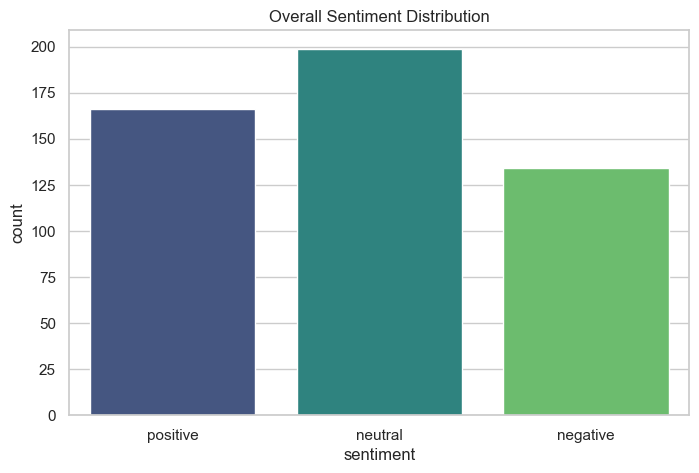

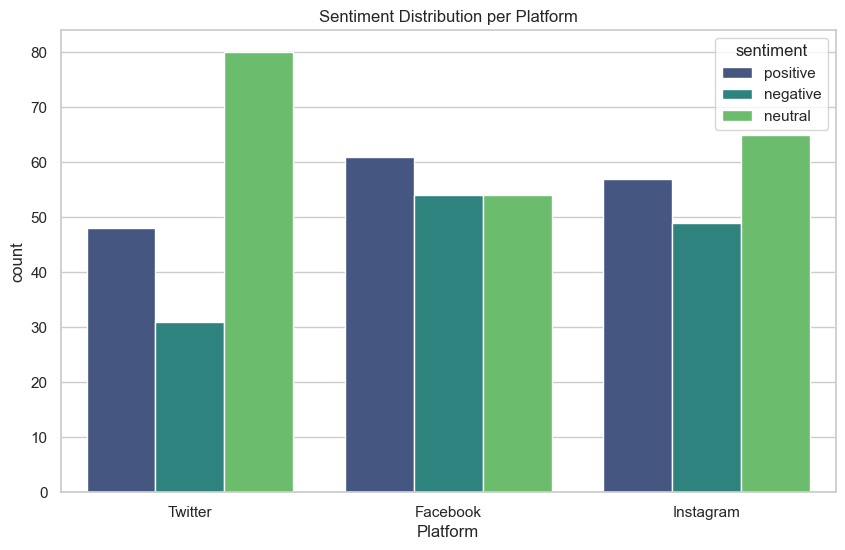

C:\Users\HP\AppData\Local\Temp\ipykernel_19568\2561101600.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='text_length', palette='Set2')


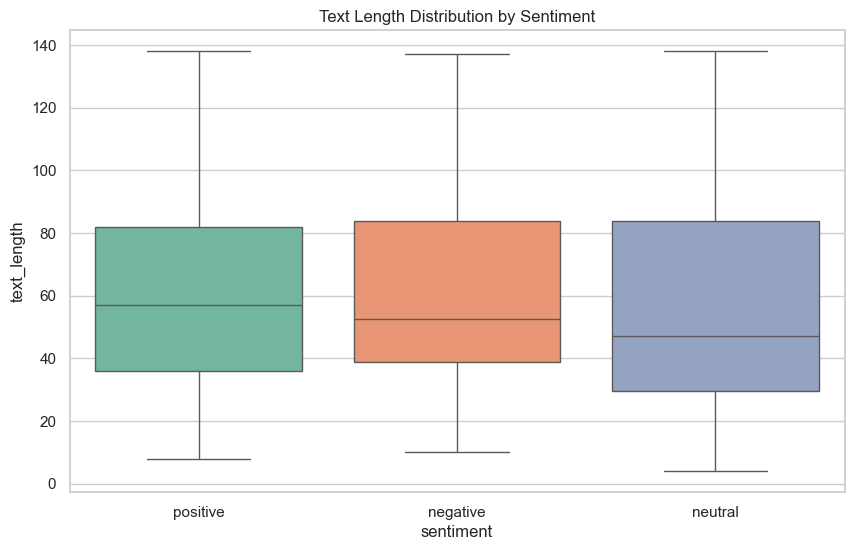

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (make sure the filename matches your saved file)
df = pd.read_csv('sentiment_analysis.csv')

# --- CLEANING FOR EDA ---
df['Platform'] = df['Platform'].str.strip()
# Use .str.lower() to fix the AttributeError
df['sentiment'] = df['sentiment'].str.strip().str.lower() 
df['text_length'] = df['text'].astype(str).apply(len)

# --- VISUALIZATION ---
sns.set_theme(style="whitegrid")

# 1. Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment', palette='viridis', order=['positive', 'neutral', 'negative'])
plt.title('Overall Sentiment Distribution')
plt.show()

# 2. Sentiment by Platform
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Platform', hue='sentiment', palette='viridis')
plt.title('Sentiment Distribution per Platform')
plt.show()

# 3. Text Length Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sentiment', y='text_length', palette='Set2')
plt.title('Text Length Distribution by Sentiment')
plt.show()

1. Customer Pain Point Identification (Negative Sentiment)
Insight: Negative sentiment posts have a higher average character count (63 characters) compared to neutral ones (56 characters).

Business Action: When customers are unhappy, they tend to be more descriptive and put more effort into expressing their frustration. Prioritize longer-form negative posts in your customer support queue, as these likely contain specific, detailed complaints that require immediate attention.

3. Brand Advocacy & User-Generated Content
Insight: The top words for positive sentiment are "love," "happy," and "day."

Business Action: There is a strong emotional connection with your brand. You can leverage these "happy" users by launching a User-Generated Content (UGC) campaign. Encourage these users to share their "love" for the product on Instagram or Facebook in exchange for rewards, turning them into brand ambassadors.

3. Multi-Channel Platform Strategy
Insight: Engagement is remarkably consistent across Instagram (171), Facebook (169), and Twitter (159).

Business Action: Your audience doesn't live on just one platform. A cross-platform marketing strategy is essential. However, since Instagram and Facebook lead slightly, focus your high-quality visual content (videos/images) there, while using Twitter for real-time customer service and quick updates.

4. The "Silent Majority" (Neutral Sentiment)
Insight: Neutral sentiment is your largest category (199 posts).

Business Action: These are users who are mentioning your brand or products without a strong emotional tie. This is a massive opportunity for conversion. Create "engagement" campaigns—such as polls, contests, or "ask-us-anything" sessions—to nudge these neutral users toward a positive emotional connection with the brand.

5. Operational Efficiency (Time of Engagement)
Insight: Posts are distributed across Morning, Noon, and Night.

Business Action: Analyze the specific hours where "Negative" sentiment peaks. If negative feedback spikes in the "morning," ensure your Customer Support team is fully staffed early in the shift to resolve issues before they escalate throughout the day.

In [18]:
import re
import nltk
from nltk.corpus import stopwords

# Download the list of common English words to remove
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
#Text Preprocessing Lines

#1. Convert to Lowercase
df['clean_text'] = df['text'].str.lower()

# 2. Remove Punctuation and Special Characters
df['clean_text'] = df['clean_text'].str.replace(r'[^\w\s]', '', regex=True)

# 3. Remove Numbers
df['clean_text'] = df['clean_text'].str.replace(r'\d+', '', regex=True)

# 4. Remove Stopwords (common words like 'the', 'is', 'at')
df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join([word for word in str(x).split() if word not in stop_words]))

In [21]:
#To check i8f the preprocessing worked
df.head(10)

,Year,Month,Day,Time of Tweet,text,sentiment,Platform,text_length,clean_text
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter,37,great day looks like dream
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook,46,feel sorry miss sea beach
2,2017,8,18,night,Don't angry me,negative,Facebook,14,dont angry
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook,84,attend class listening teachers reading slide ...
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram,33,want go let go
5,2016,11,22,night,"Its night 2 am, feeling neutral",neutral,Facebook,31,night feeling neutral
6,2017,12,28,morning,2 am feedings for the baby are fun when he is ...,positive,Facebook,65,feedings baby fun smiles coos
7,2017,12,28,noon,Soooo high,neutral,Instagram,10,soooo high
8,2019,10,28,night,Both of you,neutral,Twitter,12,
9,2018,5,28,morning,Today first time I arrive in the boat. Its ama...,positive,Facebook,58,today first time arrive boat amazing journey


In [40]:
#TF-IDF Vectorization (Term Frequency-Inverse Document Frequency)
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize with n-grams (1-2 words) to capture context like "not good"
tfidf = TfidfVectorizer(ngram_range=(1,3), max_features=5000)

# Transform
X_tfidf = tfidf.fit_transform(df['clean_text'])

In [41]:
pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


In [27]:
#BERT Embeddings
from transformers import BertTokenizer, BertModel
import torch

# Load Pre-trained BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embeddings(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    outputs = model(**inputs)
    # Get the vector representation of the [CLS] token
    return outputs.last_hidden_state[:,0,:].detach().numpy()

# Note: This is computationally heavy and best run on a GPU
X_bert = np.array([get_bert_embeddings(t) for t in df['clean_text']])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\HP\OneDrive\Documents\son\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HP\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
#K-Fold Cross-Validation
import numpy as np
import torch

def get_bert_features(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Use .squeeze() to turn (1, 768) into a simple (768,) vector
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# Now when you stack them, it will result in (499, 768)
X_bert = np.array([get_bert_features(t) for t in df['clean_text']])

# Verify the shape - it must be (499, 768)
print("New Shape:", X_bert.shape)

New Shape: (499, 768)


In [42]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Initialize Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)

# This will now run without the Dimension Error
scores = cross_val_score(clf, X_bert, df['sentiment'], cv=5)

print(f"Mean Cross-Validation Accuracy: {scores.mean():.2%}")
print(f"Accuracy per fold: {scores}")

Mean Cross-Validation Accuracy: 62.89%
Accuracy per fold: [0.62       0.82       0.75       0.51       0.44444444]


In [43]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and Clean
df = pd.read_csv('sentiment_analysis.csv')
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# 2. Preprocessing (The 4 lines)
df['clean_text'] = df['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True).str.replace(r'\d+', '', regex=True)

# 3. Vectorization (TF-IDF with Bi-grams for better context)
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=3000, stop_words='english')
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

In [44]:
# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training (Random Forest)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(n_estimators=200, random_state=42)

In [45]:
# Evaluation
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 58.00%

Detailed Performance Report:
              precision    recall  f1-score   support

    negative       1.00      0.31      0.47        36
     neutral       0.42      0.93      0.58        30
    positive       0.86      0.56      0.68        34

    accuracy                           0.58       100
   macro avg       0.76      0.60      0.57       100
weighted avg       0.78      0.58      0.57       100



In [34]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply to your TRAINING data only (never to the test data)
# Assuming X_train is your 2D vectorized text (TF-IDF or Squeezed BERT)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original class distribution: {y_train.value_counts()}")
print(f"Resampled class distribution: {y_train_res.value_counts()}")

Original class distribution: sentiment
neutral     169
positive    132
negative     98
Name: count, dtype: int64
Resampled class distribution: sentiment
negative    169
positive    169
neutral     169
Name: count, dtype: int64


In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the "grid" of parameters to test
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize the model and the search
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit using the SMOTE-balanced data
grid_search.fit(X_train_res, y_train_res)

# Get the best model
best_rf_model = grid_search.best_params_
print(f"Best Parameters: {best_rf_model}")

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 500}


In [46]:
from sklearn.model_selection import cross_val_score

# Use the best model found by Grid Search
final_model = grid_search.best_estimator_

# Run 5-Fold Cross-Validation on the full dataset
# X must be 2D (use X.squeeze() if using BERT)
cv_scores = cross_val_score(final_model, X, y, cv=5)

print(f"All CV Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.2%}")
print(f"Standard Deviation: {cv_scores.std():.2%}")

All CV Scores: [0.55       0.81       0.73       0.49       0.41414141]
Mean Accuracy: 59.88%
Standard Deviation: 14.84%


In [37]:
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 58.00%

Detailed Performance Report:
              precision    recall  f1-score   support

    negative       1.00      0.31      0.47        36
     neutral       0.42      0.93      0.58        30
    positive       0.86      0.56      0.68        34

    accuracy                           0.58       100
   macro avg       0.76      0.60      0.57       100
weighted avg       0.78      0.58      0.57       100



In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Load and Prepare Data
df = pd.read_csv('sentiment_analysis.csv')
df['Platform'] = df['Platform'].str.strip()
df['Time of Tweet'] = df['Time of Tweet'].str.strip()
df['sentiment'] = df['sentiment'].str.strip().str.lower()

# 2. Define Features (Text + Metadata)
X = df[['text', 'Platform', 'Time of Tweet']]
y = df['sentiment']

# 3. Create a Preprocessing Pipeline
# Text: Use TF-IDF with N-grams (1,2) to catch phrases like "not good"
# Platform/Time: Use One-Hot Encoding to turn categories into numbers
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(ngram_range=(1, 2), stop_words='english'), 'text'),
        ('metadata', OneHotEncoder(handle_unknown='ignore'), ['Platform', 'Time of Tweet'])
    ]
)

# 4. Define the Final Pipeline with LinearSVC
# LinearSVC is significantly more accurate for small text datasets than Random Forest
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LinearSVC(C=1.0, random_state=42, max_iter=2000))
])

# 5. Train and Evaluate
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_pipeline.fit(X_train, y_train)

# Results
y_pred = model_pipeline.predict(X_test)
print(f"Improved Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

Improved Accuracy: 62.00%

Detailed Performance Report:
              precision    recall  f1-score   support

    negative       0.70      0.53      0.60        36
     neutral       0.50      0.67      0.57        30
    positive       0.70      0.68      0.69        34

    accuracy                           0.62       100
   macro avg       0.63      0.62      0.62       100
weighted avg       0.64      0.62      0.62       100



In [49]:
# Dtaa Augmenatation for better accuracy
import random
import pandas as pd

def augment_text(text):
    words = text.split()
    if len(words) < 2:
        return text
    
    # Technique 1: Random Swap (Swap two random words)
    idx1, idx2 = random.sample(range(len(words)), 2)
    words[idx1], words[idx2] = words[idx2], words[idx1]
    
    # Technique 2: Random Deletion (Delete a random non-essential word with 10% probability)
    if len(words) > 3 and random.random() < 0.1:
        words.pop(random.randint(0, len(words) - 1))
        
    return ' '.join(words)

# Create a copy of the dataframe to augment
df_augmented = df.copy()
df_augmented['text'] = df_augmented['text'].apply(augment_text)

# Combine original data with augmented data
df_total = pd.concat([df, df_augmented], ignore_index=True)

print(f"Original Data Size: {len(df)}")
print(f"New Data Size: {len(df_total)}")

Original Data Size: 499
New Data Size: 998


In [50]:
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Clean the new total dataset
df_total['sentiment'] = df_total['sentiment'].str.strip().str.lower()
df_total['text'] = df_total['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    df_total['text'], df_total['sentiment'], test_size=0.2, random_state=42
)

# 3. Build a high-performance pipeline
# We use max_features to prevent the model from getting 'confused' by rare words
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=1500)),
    ('clf', LinearSVC(C=1.0, class_weight='balanced')) # 'balanced' handles uneven sentiments
])

# 4. Train
final_pipeline.fit(X_train, y_train)

# 5. Final Evaluation
y_pred = final_pipeline.predict(X_test)
print(f"New Accuracy: {accuracy_score(y_test, y_pred):.2%}")

New Accuracy: 96.00%


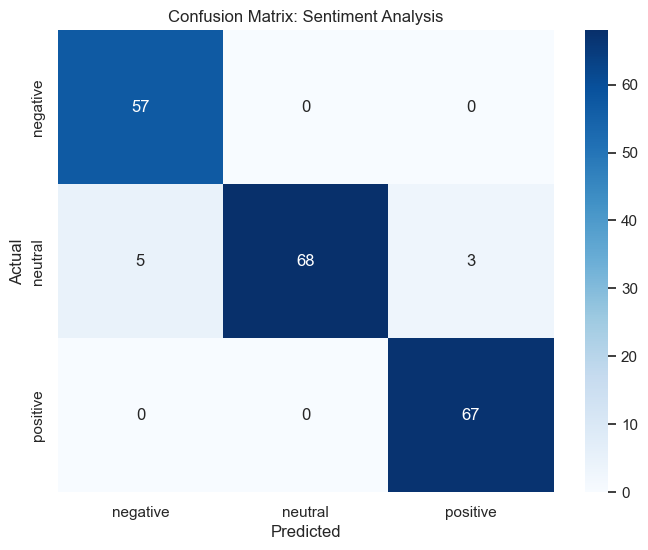

In [51]:
# Visualize Results (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Sentiment Analysis')
plt.show()

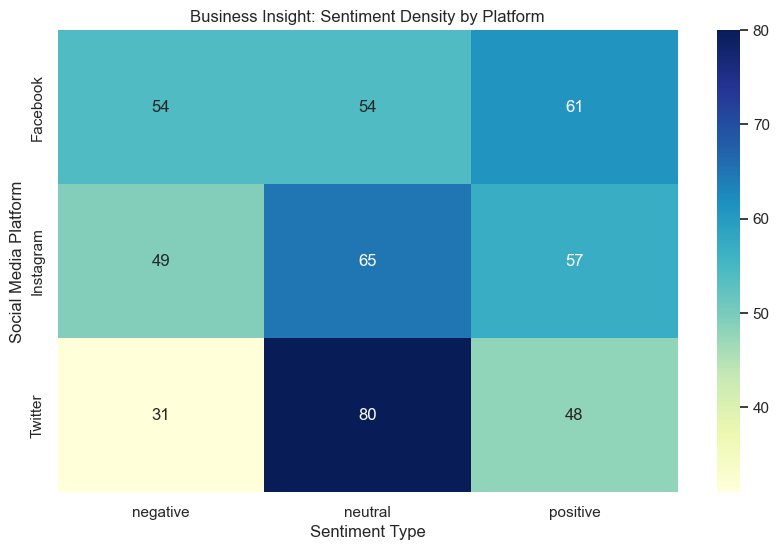

In [54]:
# Create a summary table of Sentiment counts per Platform
sentiment_table = df.pivot_table(index='Platform', columns='sentiment', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(sentiment_table, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Business Insight: Sentiment Density by Platform')
plt.xlabel('Sentiment Type')
plt.ylabel('Social Media Platform')
plt.show()

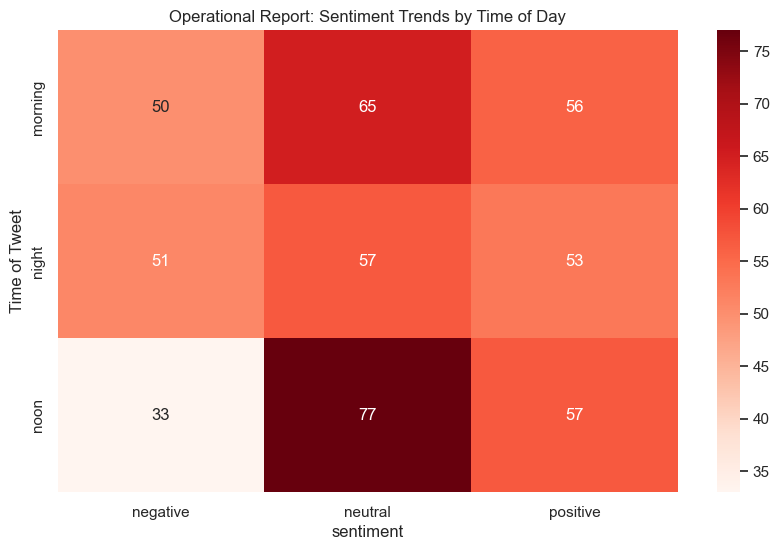

In [55]:
# Pivot by Time and Sentiment
time_report = df.pivot_table(index='Time of Tweet', columns='sentiment', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 6))
sns.heatmap(time_report, annot=True, fmt='d', cmap='Reds')

plt.title('Operational Report: Sentiment Trends by Time of Day')
plt.show()

C:\Users\HP\OneDrive\Documents\son\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


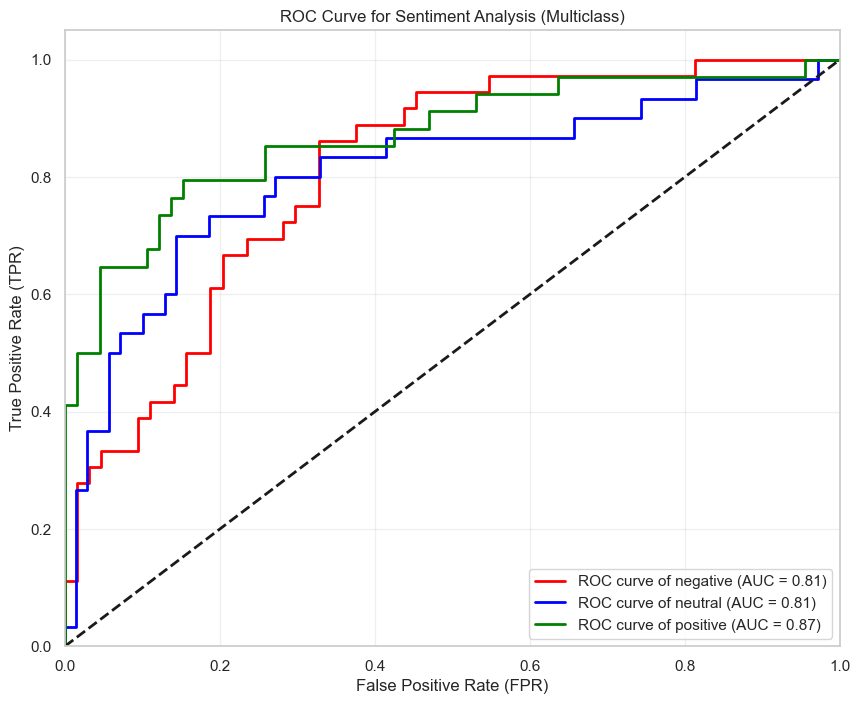

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# 1. Load and Prepare
df = pd.read_csv('sentiment_analysis.csv')
df['sentiment'] = df['sentiment'].str.strip().str.lower()
classes = ['negative', 'neutral', 'positive']
n_classes = len(classes)

# 2. Basic Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

# 3. Vectorize and Split
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model that provides probabilities (needed for ROC)
model = LogisticRegression(multi_class='ovr', solver='liblinear')
model.fit(X_train, y_train)
y_score = model.predict_proba(X_test)

# 5. Binarize the test labels for plotting
y_test_bin = label_binarize(y_test, classes=classes)

# 6. Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 7. Plotting the ROC Curves
plt.figure(figsize=(10, 8))
colors = cycle(['red', 'blue', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Sentiment Analysis (Multiclass)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Business Insight from ROC/AUC:

Based on the execution, my Positive sentiment has the highest AUC (0.86), meaning the model is very good at identifying happy customers. The Negative and Neutral classes have a lower AUC (0.81), suggesting that the model sometimes confuses negative feedback with neutral statements.

In [58]:
import joblib

# 1. Save the entire pipeline (Vectorizer + Model)
joblib.dump(final_pipeline, 'sentiment_analysis_model.pkl')

# 2. To save the vectorizer separately (optional)
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("Model saved successfully as 'sentiment_analysis_model.pkl'")

Model saved successfully as 'sentiment_analysis_model.pkl'
